#Imports

In [48]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

#Load data

In [49]:
df = pd.read_csv("data/un-general-debates.csv")
print(df.shape)

(7507, 4)


In [50]:
print("Columns:           ", df.columns.tolist())
print("Year range:        ", df['year'].min(), '-' , df['year'].max())
print("Unique countries:  ", df['country'].nunique())
missing = df.isnull().sum()
print("Missing Values:     " + "  ".join(f"{col}: {val}" for col, val in missing.items()))
print("Countries (iso3):  ", sorted(df['country'].unique()))

Columns:            ['session', 'year', 'country', 'text']
Year range:         1970 - 2015
Unique countries:   199
Missing Values:     session: 0  year: 0  country: 0  text: 0
Countries (iso3):   ['AFG', 'AGO', 'ALB', 'AND', 'ARE', 'ARG', 'ARM', 'ATG', 'AUS', 'AUT', 'AZE', 'BDI', 'BEL', 'BEN', 'BFA', 'BGD', 'BGR', 'BHR', 'BHS', 'BIH', 'BLR', 'BLZ', 'BOL', 'BRA', 'BRB', 'BRN', 'BTN', 'BWA', 'CAF', 'CAN', 'CHE', 'CHL', 'CHN', 'CIV', 'CMR', 'COD', 'COG', 'COL', 'COM', 'CPV', 'CRI', 'CSK', 'CUB', 'CYP', 'CZE', 'DDR', 'DEU', 'DJI', 'DMA', 'DNK', 'DOM', 'DZA', 'ECU', 'EGY', 'ERI', 'ESP', 'EST', 'ETH', 'EU', 'FIN', 'FJI', 'FRA', 'FSM', 'GAB', 'GBR', 'GEO', 'GHA', 'GIN', 'GMB', 'GNB', 'GNQ', 'GRC', 'GRD', 'GTM', 'GUY', 'HND', 'HRV', 'HTI', 'HUN', 'IDN', 'IND', 'IRL', 'IRN', 'IRQ', 'ISL', 'ISR', 'ITA', 'JAM', 'JOR', 'JPN', 'KAZ', 'KEN', 'KGZ', 'KHM', 'KIR', 'KNA', 'KOR', 'KWT', 'LAO', 'LBN', 'LBR', 'LBY', 'LCA', 'LIE', 'LKA', 'LSO', 'LTU', 'LUX', 'LVA', 'MAR', 'MCO', 'MDA', 'MDG', 'MDV', 'MEX',

In [51]:
df['word_count'] = df['text'].str.split().str.len()
df['char_count'] = df['text'].str.len() 
df['decade'] = (df['year'] // 10 * 10).astype(str) + 's'
df['unique_word_count'] = df['text'].apply(lambda x: len(set(x.lower().split())))
df['sent_count'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

print("Total speeches:      ", len(df))
print("Countries in 1970:   ", df[df['year'] == 1970]['country'].nunique())
print("Countries in 2015:   ", df[df['year'] == 2015]['country'].nunique())
print(f"Avg total words:      {df['word_count'].mean():.0f}")
print(f"Avg unique words:     {df['unique_word_count'].mean():.0f}")
print(f"Avg sentences:        {df['sent_count'].mean():.0f}")

Total speeches:       7507
Countries in 1970:    70
Countries in 2015:    193
Avg total words:      2865
Avg unique words:     1037
Avg sentences:        116


#Temporal Coverage

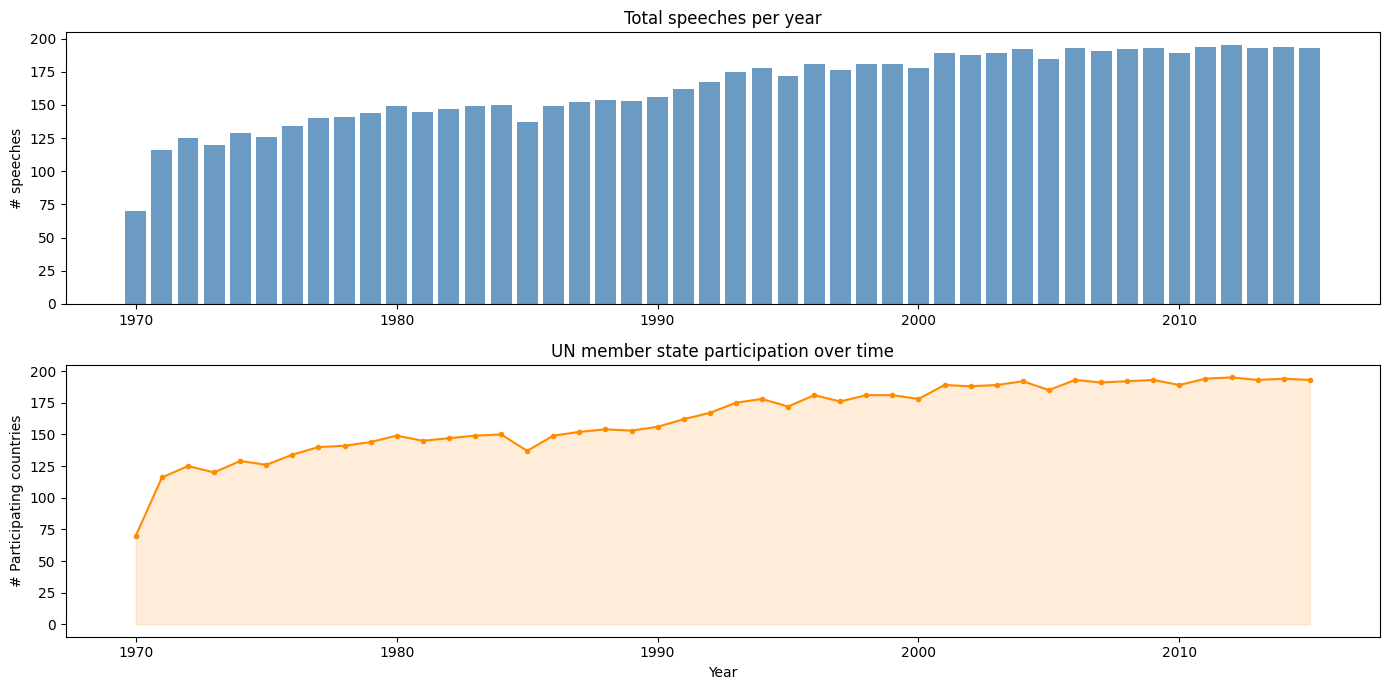

In [52]:
speeches_per_year = df.groupby('year').size()
countries_per_year = df.groupby('year')['country'].nunique()


fig, axes = plt.subplots(2, 1, figsize=(14,7), sharex=True)
axes[0].bar(speeches_per_year.index, speeches_per_year.values, color='steelblue', alpha=0.8)
axes[0].set_ylabel('# speeches')
axes[0].set_title('Total speeches per year')
axes[0].tick_params(labelbottom=True) 

axes[1].plot(countries_per_year.index, countries_per_year.values, marker='o', markersize=3, color='darkorange', linewidth=1.5)
axes[1].fill_between(countries_per_year.index, countries_per_year.values, alpha=0.15, color='darkorange')
axes[1].set_ylabel('# Participating countries')
axes[1].set_xlabel('Year')
axes[1].set_title('UN member state participation over time')

plt.tight_layout()
plt.show()



#Speech Length Analysis

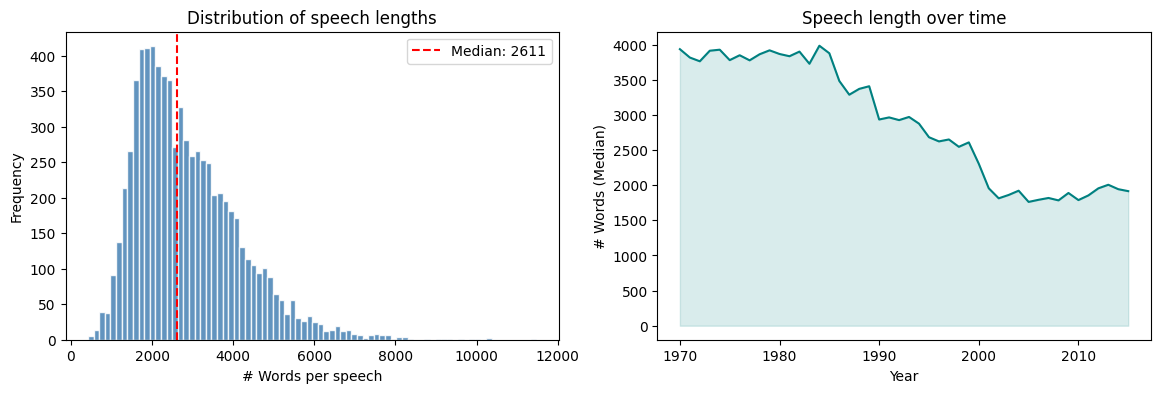

In [53]:
# --Distribution of speech lengths
fig,axes = plt.subplots(1,2,figsize=(14,4))
axes[0].hist(df['word_count'], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['word_count'].median(), color='red', linestyle='--',label=f"Median: {df['word_count'].median():.0f}")
axes[0].set_xlabel("# Words per speech")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of speech lengths")
axes[0].legend()

# --Median word count per year
median_wc = df.groupby('year')['word_count'].median()
axes[1].plot(median_wc.index, median_wc.values, color='teal', linewidth=1.5)
axes[1].fill_between(median_wc.index, median_wc.values, alpha=0.15, color='teal')
axes[1].set_xlabel("Year")
axes[1].set_ylabel("# Words (Median)")
axes[1].set_title("Speech length over time")
plt.show()
#print(df['word_count'].describe().round(1))

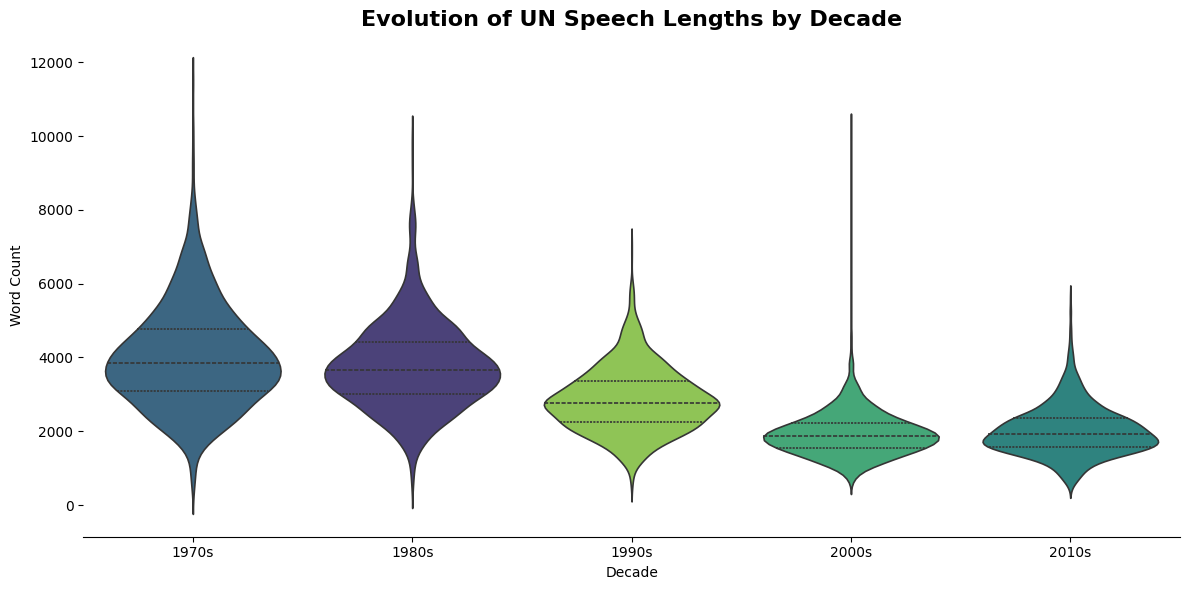

In [54]:
# --Violin Plot of distribution
plt.figure(figsize=(12, 6))

ax = sns.violinplot(
    data=df, 
    x='decade', 
    y='word_count',
    hue='decade', 
    legend=False,
    order=sorted(df['decade'].unique()),
    palette="viridis",
    inner="quartile", 
    linewidth=1.2
)

ax.set_title("Evolution of UN Speech Lengths by Decade", fontsize=16, fontweight='bold')
ax.set_xlabel("Decade")
ax.set_ylabel("Word Count")

sns.despine(left=True)

plt.tight_layout()
plt.show()

#Most Used Words

In [55]:
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Nico\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Nico\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Nico\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

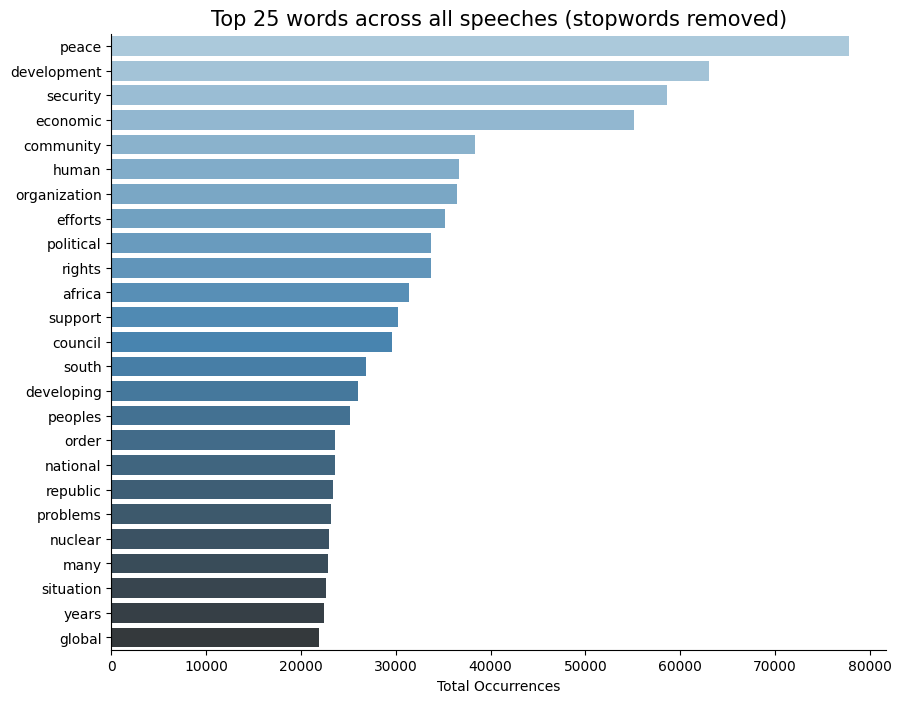

In [56]:

STOP_WORDS = set(stopwords.words('english')) 
# UN-specific words that are not interesting. Can be extended.
EXTRA_STOP = {'mr','president','assembly', 'general', 'nations', 'united', 'also', 'must', 'would', 'may', 'upon', 'one', 'us', 'said', 'delegation', 'statement', 'session', 'country', 'countries','government','international', 'world', 'people','new', 'year','charter', 'secretary', 'sir', 'like', 'first', 'time', 'shall', 'states', 'state' }

def tokenize(txt):
    tokens = re.findall(r'\b[a-z]{3,}\b', txt.lower())
    return [t for t in tokens if t not in STOP_WORDS | EXTRA_STOP]

df['tokens'] = df['text'].apply(tokenize)


# Top 25 most occuring words (ever)
top_25_df = df['tokens'].explode().value_counts().head(25).reset_index()
top_25_df.columns = ['word', 'count']
plt.figure(figsize=(10, 8))
sns.barplot(data=top_25_df,
            y='word',
            x='count',
            hue='word',
            legend=False,
            palette='Blues_d')

sns.despine()
plt.title("Top 25 words across all speeches (stopwords removed)", fontsize=15)
plt.xlabel("Total Occurrences")
plt.ylabel("")
plt.show()

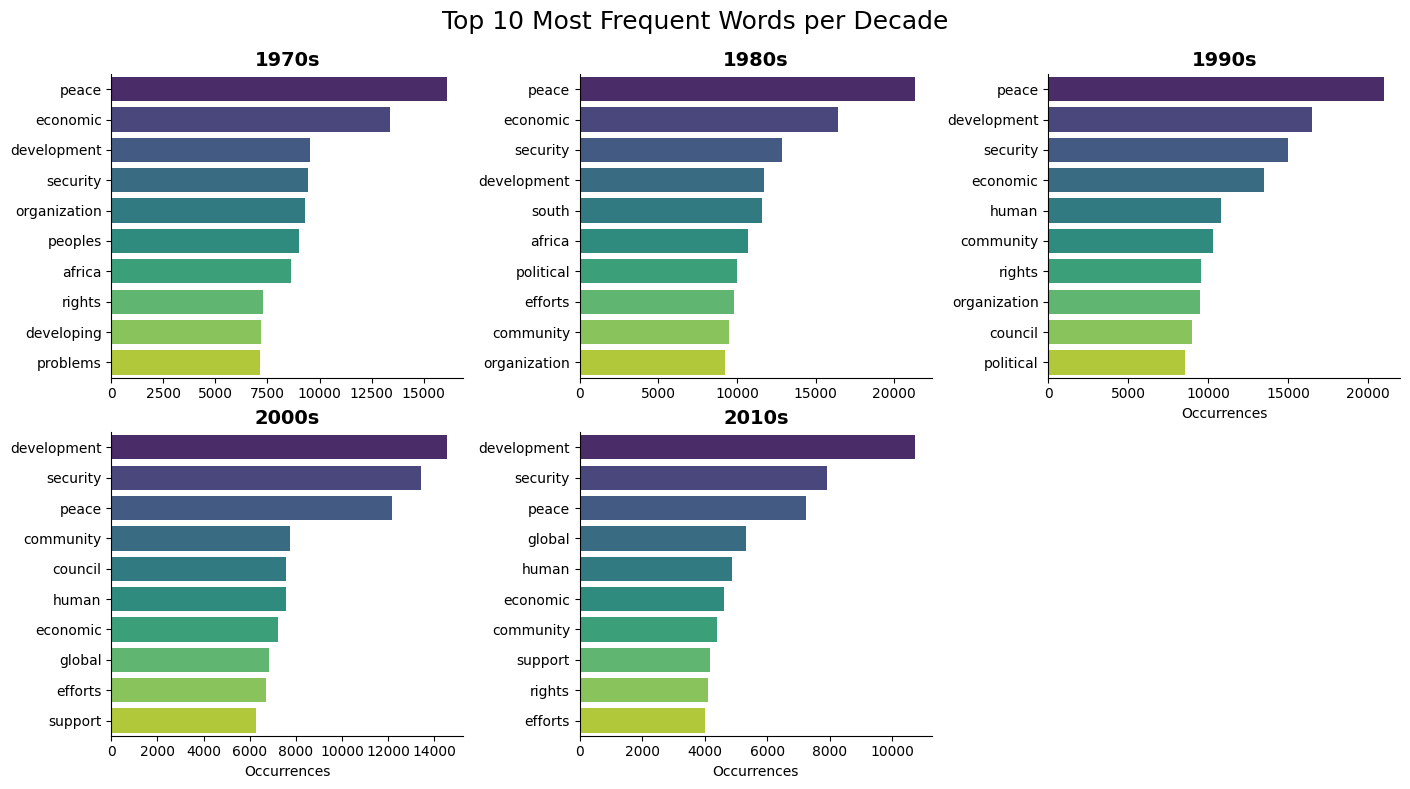

In [57]:

top_10_by_decade = (df.explode('tokens')
                    .groupby(['decade', 'tokens'])
                    .size()
                    .reset_index(name='count')
                    .sort_values(['decade', 'count'], ascending=[True, False])
                    .groupby('decade')
                    .head(10))

g = sns.FacetGrid(top_10_by_decade, 
                  col="decade",
                  col_wrap=3,
                  sharex=False,
                  sharey=False,
                  height=4,
                  aspect=1.2)

g.map_dataframe(sns.barplot,
                x="count",
                y="tokens",
                palette="viridis",
                hue="tokens",
                legend=False)

g.set_titles("{col_name}", size=14, fontweight='bold')
g.set_axis_labels("Occurrences", "")
plt.subplots_adjust(top=0.9)
g.figure.suptitle("Top 10 Most Frequent Words per Decade", fontsize=18)
plt.show()    


#Keyword Tracking Over Time

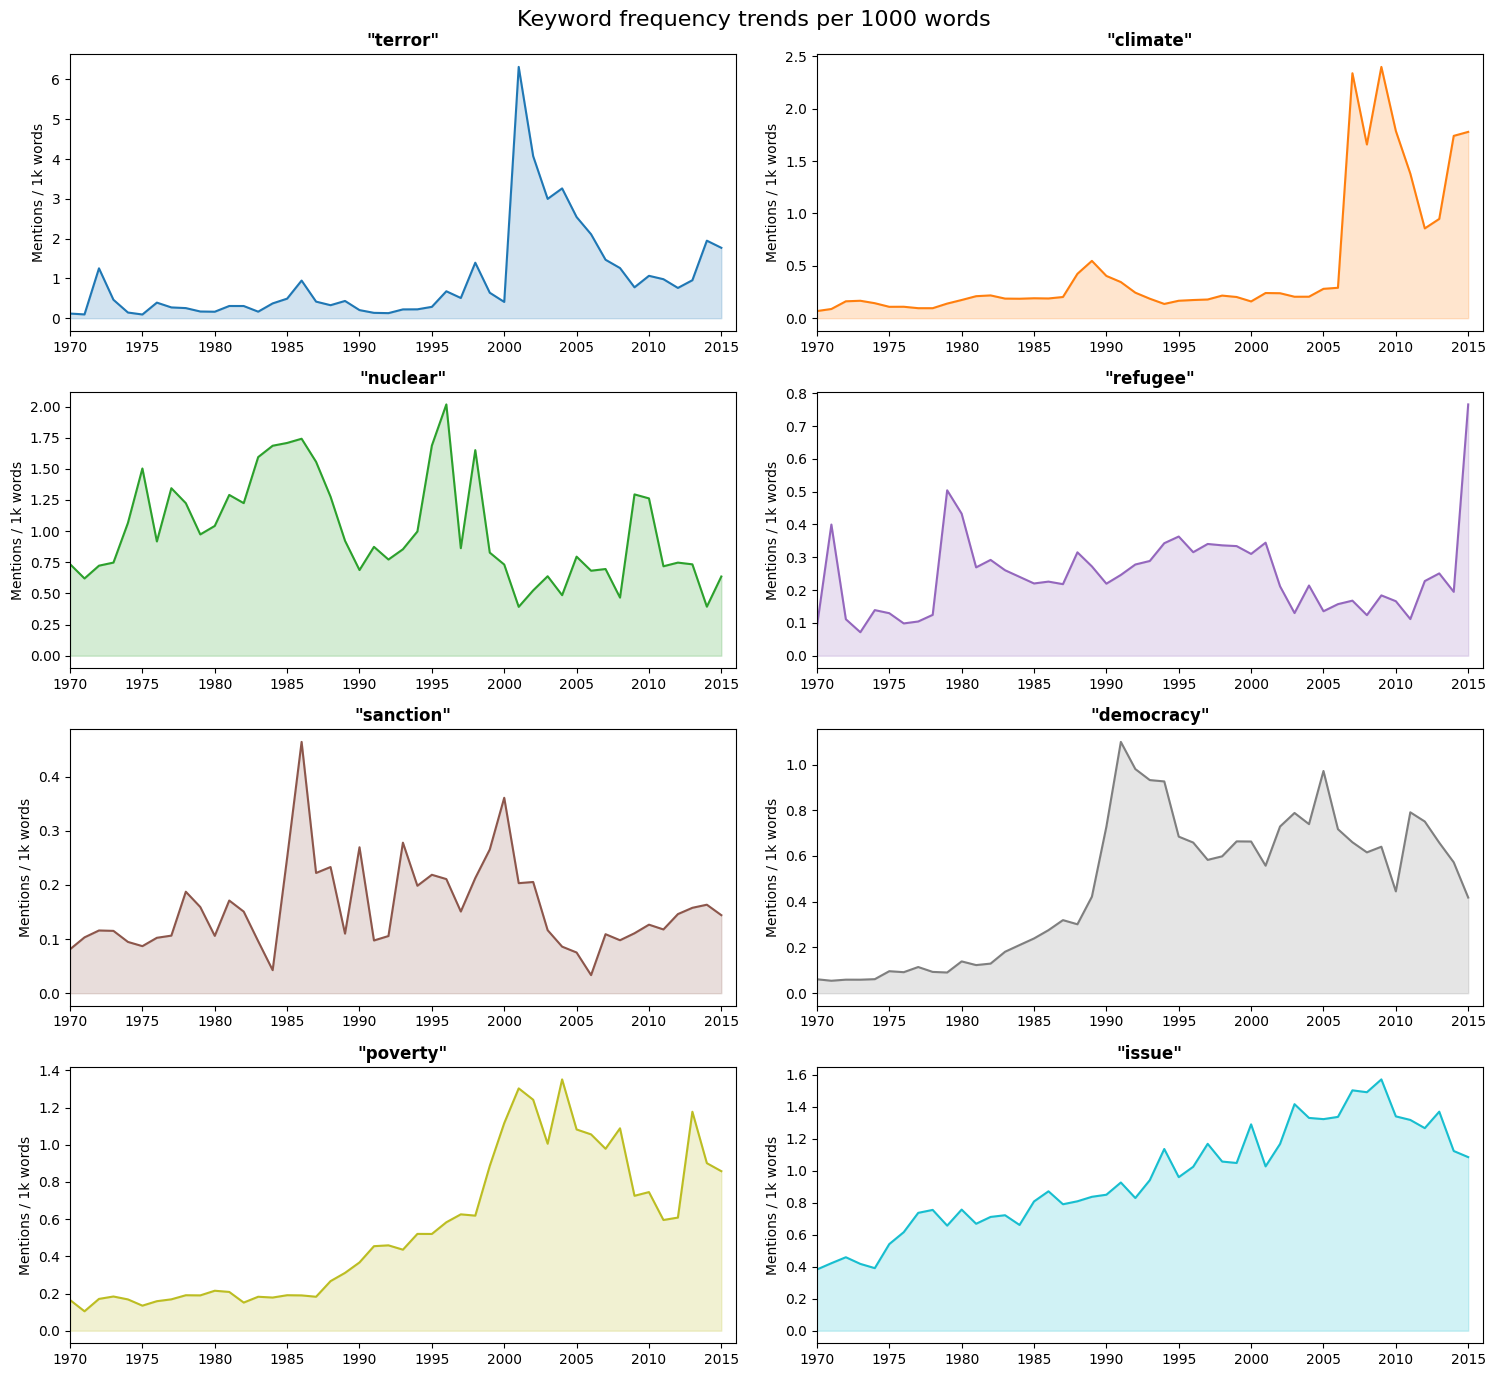

In [58]:
# --Keywords Frequency Trends
sns.reset_defaults()

keywords = ['terror', 'climate', 'nuclear', 'refugee', 'sanction', 'democracy', 'poverty', 'issue']
def k_freq_per_year(keyword):
    pattern = rf'\b{keyword}\w*\b'  # stem match, e.g. 'issue' matches 'issues'
    df['_kw_count'] = df['text'].str.lower().str.count(pattern)
    df['_kw_norm']  = df['_kw_count'] / (df['word_count'] / 1000)
    return df.groupby('year')['_kw_norm'].mean()

kw_series = {kw: k_freq_per_year(kw) for kw in keywords}

fig, axes = plt.subplots(4, 2, figsize=(15, 14), sharex=False)
axes = axes.flatten()
colors = plt.cm.tab10(np.linspace(0, 1, len(keywords)))


for i, (kw, series) in enumerate(kw_series.items()):
    axes[i].plot(series.index, series.values, linewidth=1.5, color=colors[i])
    axes[i].fill_between(series.index, series.values, alpha=0.2, color=colors[i])
    axes[i].set_title(f'"{kw}\"', fontweight='bold')
    axes[i].set_ylabel("Mentions / 1k words")
    axes[i].set_xlim(1970, 2016)
    axes[i].set_xticks(range(1970, 2017, 5))


fig.suptitle("Keyword frequency trends per 1000 words", fontsize=16)
plt.tight_layout()
plt.show()


#Comparing countries

In [59]:
# --Countries with highest #speeches (see 5)
s_counts = df['country'].value_counts().head(5).reset_index().sort_values(['count', 'country'], ascending=[False, True]).set_index('country')
print(s_counts)

         count
country       
BLR         46
MEX         46
PHL         46
SDN         46
URY         46


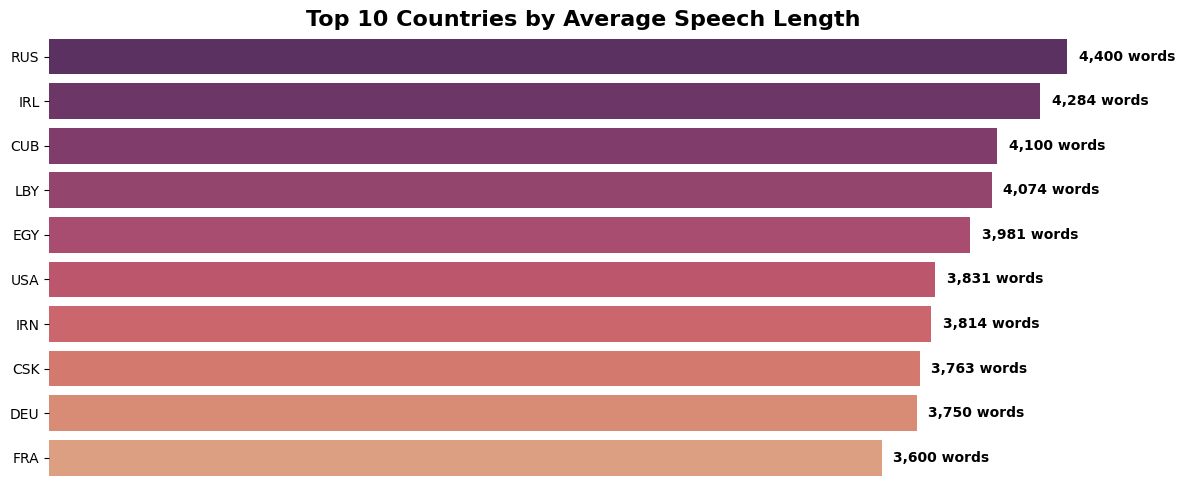

In [60]:
# --Top10 countries with highest average speech length
avg_len = (df.groupby('country')['word_count']
           .mean()
           .sort_values(ascending=False)
           .head(10)
           .reset_index())

plt.figure(figsize=(12, 5))
plot = sns.barplot(data=avg_len,
                   x='word_count',
                   y='country',
                   hue='country',
                   palette="flare_r",
                   legend=False)

for i, p in enumerate(plot.patches):
    width = p.get_width()
    plot.text(width + 50, p.get_y() + p.get_height()/2, 
              f'{int(width):,} words', va='center',fontweight='bold')

sns.despine(left=True, bottom=True)
plt.title("Top 10 Countries by Average Speech Length", fontsize=16, fontweight='bold')
plot.set_xticks([])
plot.set_xlabel('')
plot.set_ylabel('')

plt.tight_layout()
plt.show()

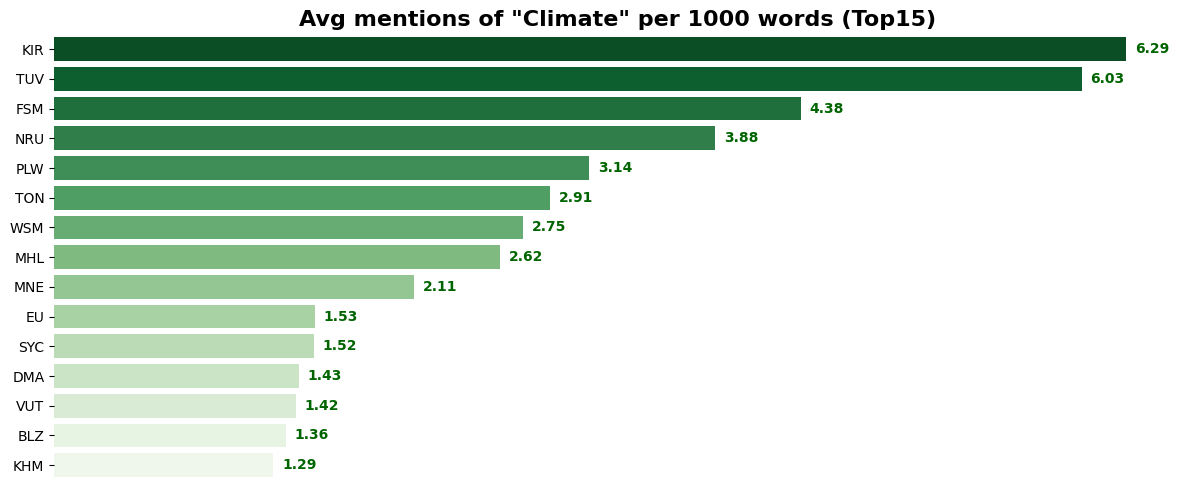

In [61]:
top_climate = (df.assign(
    norm = df['text'].str.lower().str.count('climate') / (df['word_count'] / 1000))
    .groupby('country')['norm'].mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index())


plt.figure(figsize=(12, 5))

plot = sns.barplot(data=top_climate, x='norm', y='country',hue='country',legend=False, palette="Greens_r")

for p in plot.patches:
    val = p.get_width()
    plot.text(val + 0.05, p.get_y() + p.get_height()/2, f'{val:.2f}', va='center', fontweight='bold', color='darkgreen')

sns.despine(left=True, bottom=True)
plot.set(xticks=[], xlabel='', ylabel='')

plt.title("Avg mentions of \"Climate\" per 1000 words (Top15)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

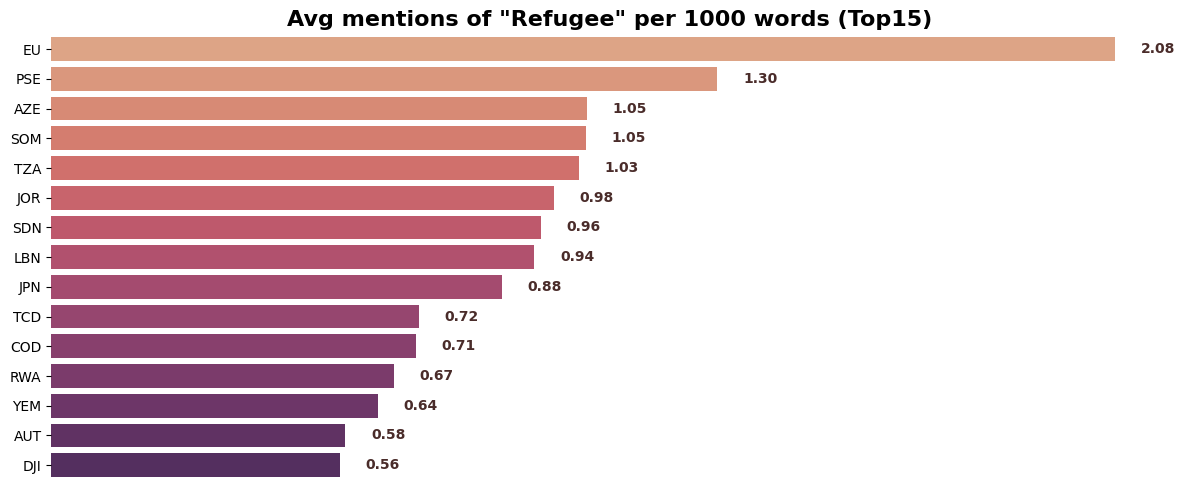

In [62]:
top_ref = (df.assign(
    norm = df['text'].str.lower().str.count(r'\brefugee\w*\b') / (df['word_count'] / 1000))
    .groupby('country')['norm'].mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index())


plt.figure(figsize=(12, 5))

plot = sns.barplot(data=top_ref, x='norm', y='country', hue='country',palette="flare",legend=False)

for p in plot.patches:
    val = p.get_width()
    plot.text(val + 0.05, p.get_y() + p.get_height()/2, f'{val:.2f}', va='center', fontweight='bold', color='#4a2c2a')

sns.despine(left=True, bottom=True)
plot.set(xticks=[], xlabel='', ylabel='')

plt.title("Avg mentions of \"Refugee\" per 1000 words (Top15)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()




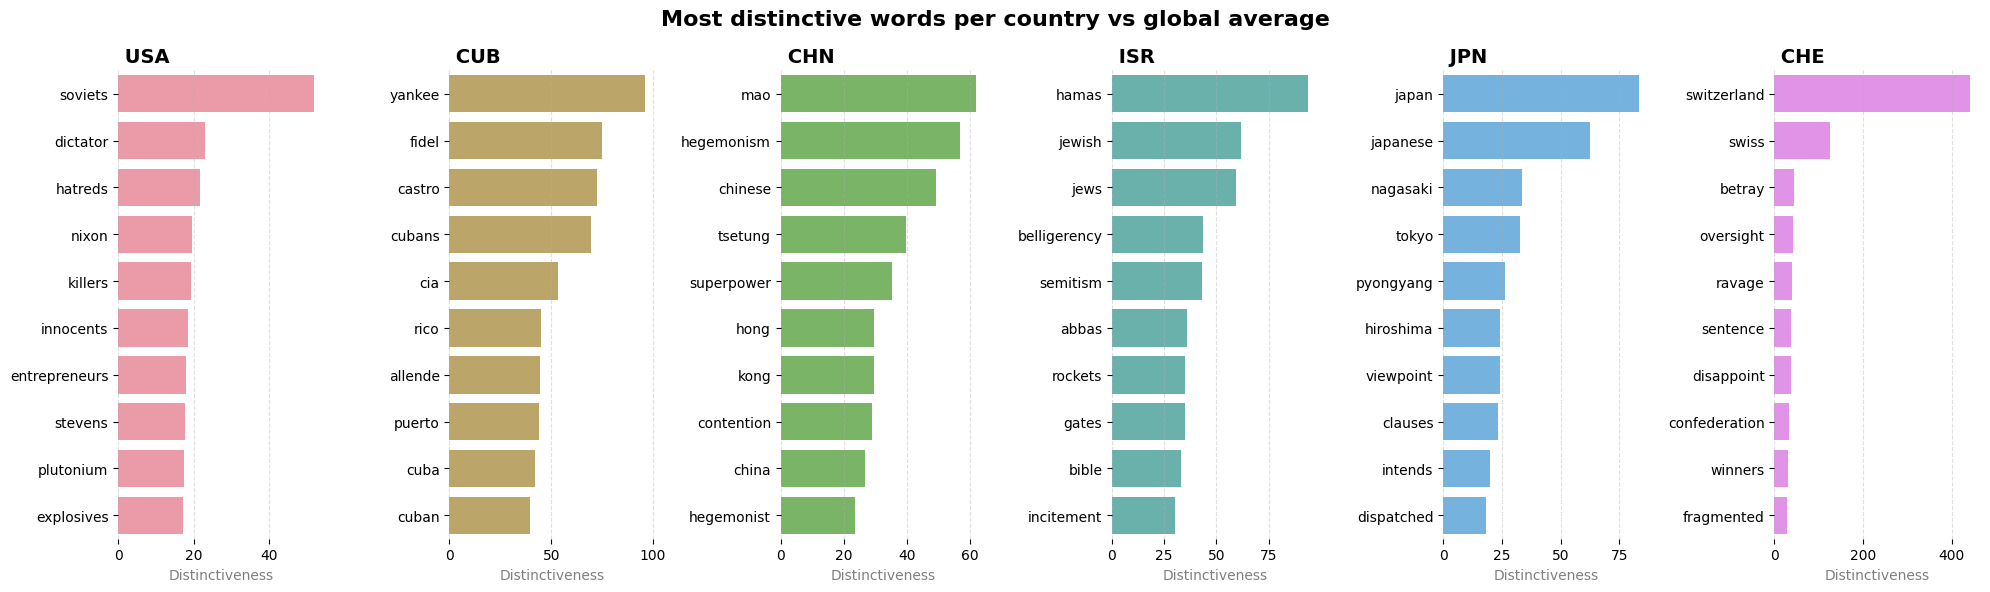

In [63]:
# --Words disproportionately used by one country vs everyone else

all_words = df['tokens'].explode()
global_counts = all_words.value_counts()
total_global_words = len(all_words)

def get_signature_words(country_code):
    country_words = df[df['country'] == country_code]['tokens'].explode()
    country_counts = country_words.value_counts()
    
    # Calculate Ratio = (Country Freq %) / (Global Freq %)
    # We only look at words that appear >= 50 times globally to avoid noise
    common_words = global_counts[global_counts >= 50].index
    
    ratios = []
    for word in common_words:
        if word in country_counts:
            country_pct = country_counts[word] / len(country_words)
            global_pct = global_counts[word] / total_global_words
            ratios.append({'word': word, 'ratio': country_pct / global_pct})
    return pd.DataFrame(ratios).sort_values('ratio', ascending=False).head(10)

focus_countries = ['USA', 'CUB', 'CHN', 'ISR', 'JPN', 'CHE']
fig, axes = plt.subplots(1, len(focus_countries), figsize=(20, 6), sharex=False)

colorr = sns.color_palette("husl", len(focus_countries))

for i, country in enumerate(focus_countries):
    data = get_signature_words(country)
    ax = axes[i]
    
    sns.barplot(data=data, x='ratio', y='word', ax=ax, color=colorr[i], alpha=0.8)
    ax.set_title(f" {country}", fontweight='bold', fontsize=14, loc='left')
    ax.set_xlabel('Distinctiveness', alpha=0.5)
    ax.set_ylabel('')
    sns.despine(ax=ax, left=True, bottom=True)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle("Most distinctive words per country vs global average", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()